# Does configuration recovery actually recover experiment circuit states?

Workflow:
- Run circuits with yaml/parameters_recovery_coverage.yaml
- Train the CRBM models
- Run the Trotter statevector simulation with scripts/trotter.py (need parallel GPU)
- Compute the coverages with scripts/recovery_coverage.py

In [1]:
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.tasks.open_output import open_output
from skqd_z2lgt.tasks.preprocess import load_reco

In [2]:
pkgpath = Path('/data/iiyama/2dz2/experiment_400k_aachen')
parameters = open_output(str(pkgpath))

In [3]:
with h5py.File(pkgpath / 'recovery_coverage.h5', 'r') as source:
    coverage_ideal = source['coverage_ideal'][()]
    probs_raw = [source[f'probs_raw/s{step}'][()] for step in parameters.circuit.sampled_steps]
    coverage_local = source['coverage_local'][()]
    coverage_crbm = source['coverage_crbm'][()]

### Coverage plot

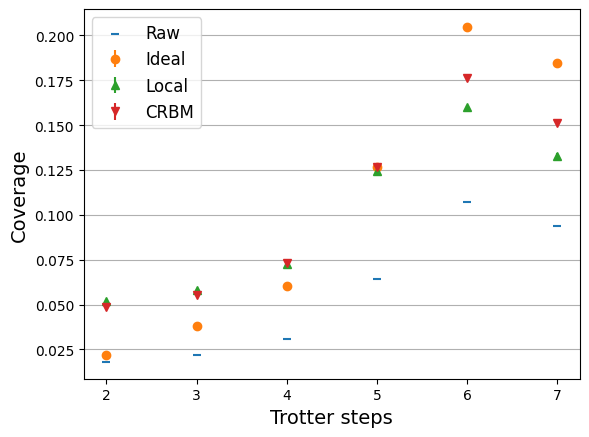

In [4]:
x = parameters.circuit.sampled_steps
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.scatter(x, [np.sum(probs) for probs in probs_raw], marker='_', color=colors[0], label='Raw')
plt.errorbar(x, np.mean(coverage_ideal, axis=1),
             yerr=np.std(coverage_ideal, axis=1), linestyle='none', marker='o', color=colors[1], label='Ideal')
plt.errorbar(x, np.mean(coverage_local, axis=1),
             yerr=np.std(coverage_local, axis=1), linestyle='none', marker='^', color=colors[2], label='Local')
plt.errorbar(x, np.mean(coverage_crbm, axis=1),
             yerr=np.std(coverage_crbm, axis=1), linestyle='none', marker='v', color=colors[3], label='CRBM')
plt.legend(fontsize=12)
plt.xlabel('Trotter steps', fontsize=14)
plt.ylabel('Coverage', fontsize=14)
# plt.ylim(0., 0.16)
plt.grid(axis='y')

### Hot spots?

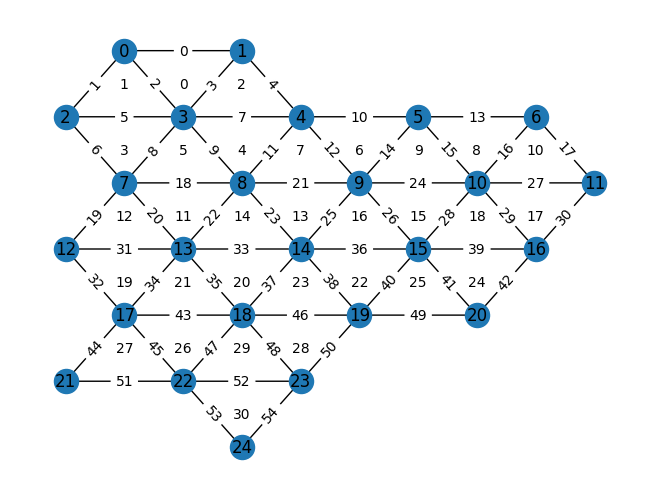

In [5]:
lattice = TriangularZ2Lattice(parameters.lgt.lattice)
lattice.draw_graph();

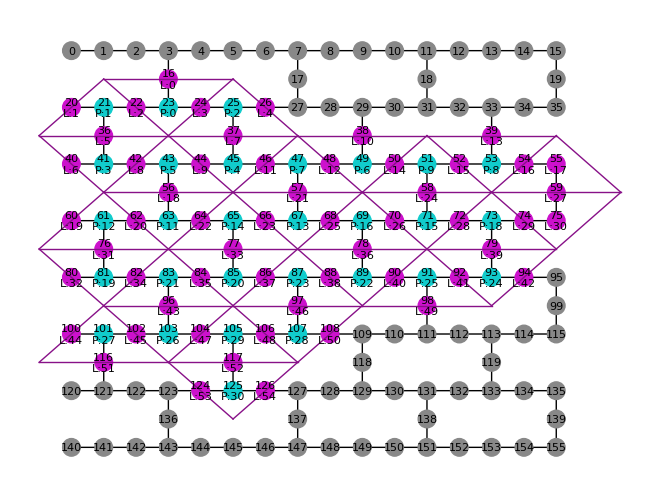

In [6]:
service = QiskitRuntimeService(instance=parameters.runtime.instance)
backend = service.backend(parameters.runtime.backend, use_fractional_gates=True)
lattice.draw_qubit_graph(parameters.circuit.layout, backend.coupling_map);

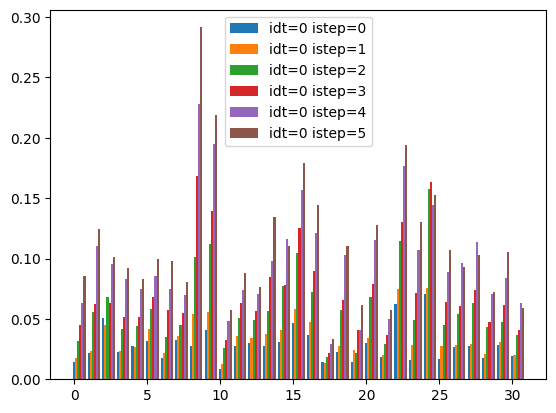

In [7]:
ref_data = load_reco(parameters, etype='ref')
xbase = np.arange(lattice.num_plaquettes)
nseries = len(parameters.circuit.dts) * len(parameters.circuit.sampled_steps)
width = 1. / (nseries + 1.)
iseries = 0
for idt in range(len(parameters.circuit.dts)):
    for istep in range(len(parameters.circuit.sampled_steps)):
        mean_activation = np.mean(ref_data[idt][istep][1], axis=0)
        plt.bar(xbase + width * iseries, mean_activation[::-1], width=width, label=f'idt={idt} istep={istep}')
        iseries += 1
plt.legend();